In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.applications import MobileNetV2, ResNet50V2
from keras.layers import Dense, GlobalAveragePooling2D, Dropout, Concatenate, Input
from keras.models import Model
from keras.callbacks import EarlyStopping, ModelCheckpoint
from keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import os
import cv2

I0000 00:00:1777645778.559857   21207 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777645779.933632   21207 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
# Environments
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# Variables
ROOT_DIR = "/media/DATA/.kaggle/autism-spectrum"
EPOCHS = 20
BATCH_SIZE = 32
IMG_SIZE = 224
IMG_SHAPE = (IMG_SIZE, IMG_SIZE)
ROTATION_DEGREE = 20

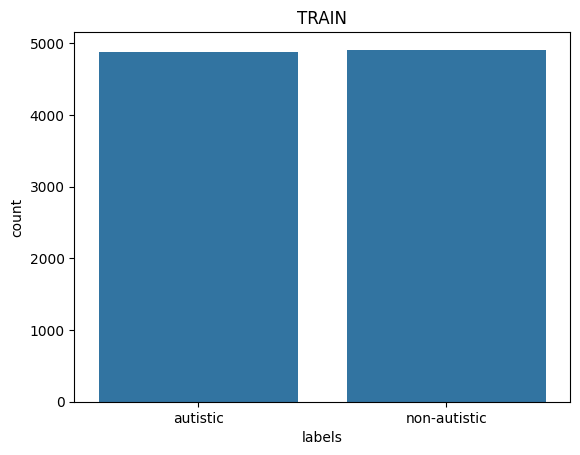

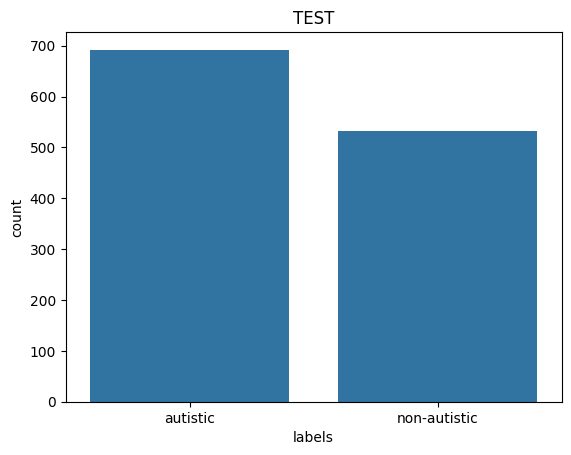

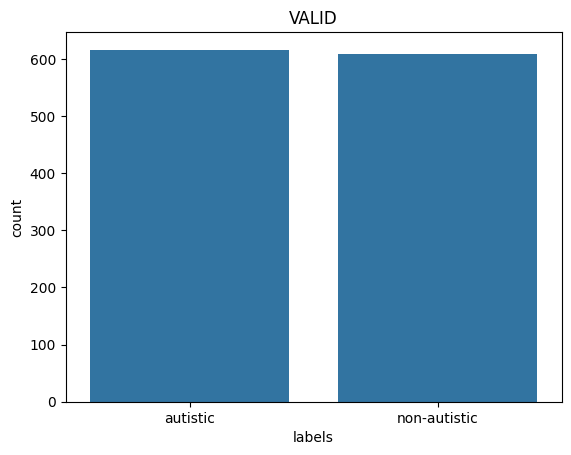

In [3]:
train_df = pd.read_csv(f"{ROOT_DIR}/Cleaned Dataset/Project/cleaned_train_80.csv")
test_df = pd.read_csv(f"{ROOT_DIR}/Cleaned Dataset/Project/cleaned_test_10.csv")
valid_df = pd.read_csv(f"{ROOT_DIR}/Cleaned Dataset/Project/cleaned_valid_10.csv")

sns.countplot(x='labels',data=train_df)
plt.title('TRAIN')
plt.show()
sns.countplot(x='labels',data=test_df)
plt.title('TEST')
plt.show()
sns.countplot(x='labels',data=valid_df)
plt.title('VALID')
plt.show()

In [4]:
train_datagen_aug = ImageDataGenerator(
    rescale=1./255,
    rotation_range=ROTATION_DEGREE,
    horizontal_flip=True,
)

train_gen_aug = train_datagen_aug.flow_from_dataframe(
    dataframe=train_df,
    x_col="image_path",             # column with image names
    y_col="labels",                # column with labels
    target_size=IMG_SHAPE,       # resize images
    batch_size=BATCH_SIZE,
    class_mode="binary",     # or "binary", "sparse", or None
    shuffle=True
)

train_datagen_no_aug = ImageDataGenerator(
    rescale=1./255
)

train_gen_no_aug = train_datagen_no_aug.flow_from_dataframe(
    dataframe=train_df,
    x_col="image_path",             # column with image names
    y_col="labels",                # column with labels
    target_size=IMG_SHAPE,       # resize images
    batch_size=BATCH_SIZE,
    class_mode="binary",     # or "binary", "sparse", or None
    shuffle=True
)

Found 9796 validated image filenames belonging to 2 classes.
Found 9796 validated image filenames belonging to 2 classes.


In [5]:
test_datagen_aug = ImageDataGenerator(
    rescale=1./255,
    rotation_range=ROTATION_DEGREE,       # Randomly rotates images by up to 20 degrees
    horizontal_flip=True,    # Flips images horizontally
)

test_gen_aug = test_datagen_aug.flow_from_dataframe(
    dataframe=test_df,
    x_col="image_path",             # column with image names
    y_col="labels",                # column with labels
    target_size=IMG_SHAPE,       # resize images
    batch_size=BATCH_SIZE,
    class_mode="binary",     # or "binary", "sparse", or None
    shuffle=False
)

test_datagen_no_aug = ImageDataGenerator(
    rescale=1./255
)

test_gen_no_aug = test_datagen_no_aug.flow_from_dataframe(
    dataframe=test_df,
    x_col="image_path",             # column with image names
    y_col="labels",                # column with labels
    target_size=IMG_SHAPE,       # resize images
    batch_size=BATCH_SIZE,
    class_mode="binary",     # or "binary", "sparse", or None
    shuffle=False
)

Found 1224 validated image filenames belonging to 2 classes.


Found 1224 validated image filenames belonging to 2 classes.


In [6]:
valid_datagen_aug = ImageDataGenerator(
    rescale=1./255,
    rotation_range=ROTATION_DEGREE,
    horizontal_flip=True,
)

valid_gen_aug = valid_datagen_aug.flow_from_dataframe(
    dataframe=valid_df,
    x_col="image_path",             # column with image names
    y_col="labels",                # column with labels
    target_size=IMG_SHAPE,       # resize images
    batch_size=BATCH_SIZE,
    class_mode="binary",     # or "binary", "sparse", or None
)

valid_datagen_no_aug = ImageDataGenerator(
    rescale=1./255
)

valid_gen_no_aug = valid_datagen_no_aug.flow_from_dataframe(
    dataframe=valid_df,
    x_col="image_path",             # column with image names
    y_col="labels",                # column with labels
    target_size=IMG_SHAPE,       # resize images
    batch_size=BATCH_SIZE,
    class_mode="binary",     # or "binary", "sparse", or None
)

Found 1224 validated image filenames belonging to 2 classes.
Found 1224 validated image filenames belonging to 2 classes.


In [7]:
def visualisasi_preprocessing_aug(image_path):
    # 1. Load Original Image
    img_orig = cv2.imread(image_path)
    img_orig = cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)
    orig_shape = img_orig.shape
    
    # 2. Resize (Skenario Percobaan 1 & 3: 224x224)
    target_size = (224, 224)
    img_resized = cv2.resize(img_orig, target_size)
    
    # 3. Augmentasi (Horizontal Flip & Rotation)
    # Kita pake layer preprocessing Keras biar simpel
    data_augmentation_rotation = tf.keras.Sequential([
        # tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.05), # Sekitar 72 derajat
    ])

    data_augmentation_flip = tf.keras.Sequential([
        tf.keras.layers.RandomFlip("horizontal"),
        # tf.keras.layers.RandomRotation(0.2), # Sekitar 72 derajat
    ])
    
    # Tambah dimensi batch buat augmentasi (rotasi)
    img_aug_rotation = data_augmentation_rotation(tf.expand_dims(img_resized, 0))
    img_aug_rotation = tf.cast(img_aug_rotation[0], tf.uint8)

    # Tambah dimensi batch buat augmentasi (horizontal flip)
    img_aug_flip = data_augmentation_flip(tf.expand_dims(img_resized, 0))
    img_aug_flip = tf.cast(img_aug_flip[0], tf.uint8)

    # Plotting
    plt.figure(figsize=(15, 5))
    
    # # Tampilan Original
    # plt.subplot(1, 3, 1)
    # plt.imshow(img_orig)
    # plt.title(f"Original\n({orig_shape[0]}x{orig_shape[1]})")
    # plt.axis('off')
    
    # Tampilan Resized
    plt.subplot(1, 3, 1)
    plt.imshow(img_orig)
    plt.title(f"Original\n({orig_shape[0]}x{orig_shape[1]})")
    plt.axis('off')
    
    # Tampilan Augmented
    plt.subplot(1, 3, 2)
    plt.imshow(img_aug_rotation)
    plt.title("Augmented\n(Rotation)")
    plt.axis('off')

    # Tampilan Augmented
    plt.subplot(1, 3, 3)
    plt.imshow(img_aug_flip)
    plt.title("Augmented\n(Horizontal Flip)")
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

visualisasi_preprocessing_aug("/media/DATA/.kaggle/autism-spectrum/ASD Data/ASD Data/Train/autism/0001.jpg")

InternalError: cudaSetDevice() on GPU:0 failed. Status: out of memory

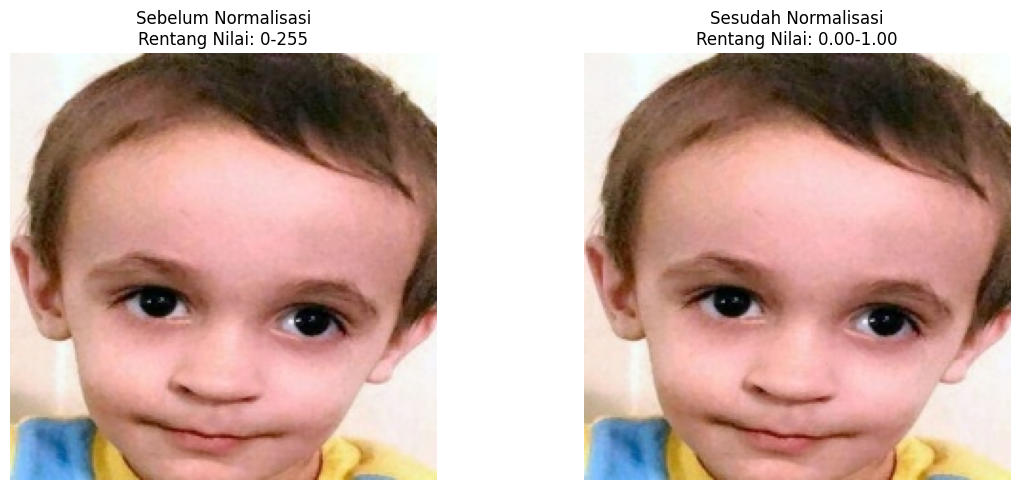

In [ ]:
def visualisasi_normalisasi(img_path):
    # 1. Load Original (0-255)
    img = tf.keras.utils.load_img(img_path, target_size=(224, 224))
    img_array = tf.keras.utils.img_to_array(img)
    
    # 2. Normalisasi (Contoh: Scaling ke [0, 1])
    # Di Deep Learning, ini ngebantu konvergensi model lebih cepet
    img_normalized = img_array / 255.0 
    
    # 3. Plotting perbandingan
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    
    # Sebelum Normalisasi
    ax[0].imshow(img_array.astype('uint8'))
    ax[0].set_title(f"Sebelum Normalisasi\nRentang Nilai: {int(np.min(img_array))}-{int(np.max(img_array))}")
    ax[0].axis('off')
    
    # Sesudah Normalisasi
    ax[1].imshow(img_normalized)
    ax[1].set_title(f"Sesudah Normalisasi\nRentang Nilai: {np.min(img_normalized):.2f}-{np.max(img_normalized):.2f}")
    ax[1].axis('off')
    
    plt.tight_layout()
    plt.show()

visualisasi_normalisasi("/media/DATA/.kaggle/autism-spectrum/ASD Data/ASD Data/Train/autism/0001.jpg")

In [ ]:
# --- BUILD DUAL-BACKBONE MODEL (FIXED) ---
num_classes = len(train_gen.class_indices)
# 1 single input
inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

# 2 backbones: instantiate WITHOUT input_shape so they don't create their own Input layers
mobilenet_backbone = MobileNetV2(include_top=False, weights="imagenet")
resnet_backbone = ResNet50V2(include_top=False, weights="imagenet")

# Freeze both initially
mobilenet_backbone.trainable = False
resnet_backbone.trainable = False

# Call both backbones on the SAME input tensor
m_feat = mobilenet_backbone(inputs)      # feature map from MobileNet
r_feat = resnet_backbone(inputs)         # feature map from ResNet

# Pool and combine
m_pool = GlobalAveragePooling2D()(m_feat)
r_pool = GlobalAveragePooling2D()(r_feat)

combined = Concatenate()([m_pool, r_pool])
combined = Dense(512, activation="relu")(combined)
combined = Dropout(0.5)(combined)

outputs = Dense(1, activation="sigmoid")(combined)

model = Model(inputs=inputs, outputs=outputs)

model.compile(optimizer=Adam(), loss="binary_crossentropy", metrics=["accuracy"])

model.summary()

/tmp/ipykernel_2110/1861757166.py:7: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  mobilenet_backbone = MobileNetV2(include_top=False, weights="imagenet")


Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_12      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_2… │ (None, 7, 7,      │  2,257,984 │ input_layer_12[0… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50v2          │ (None, 7, 7,      │ 23,564,800 │ input_layer_12[0… │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50v2[0][0]  │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 3328)      │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 512)       │  1,704,448 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 512)       │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1)         │        513 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 27,527,745 (105.01 MB)

 Trainable params: 1,704,961 (6.50 MB)

 Non-trainable params: 25,822,784 (98.51 MB)

In [ ]:
# === CALLBACKS ===
checkpoint_aug = ModelCheckpoint("asr_s1_aug.keras", monitor="accuracy", save_best_only=True)
earlystop_aug = EarlyStopping(monitor="accuracy", patience=3, restore_best_weights=True)

In [ ]:
# === TRAIN ===
history_aug = model.fit(
    train_gen_aug,
    epochs=EPOCHS,
    validation_data=valid_gen_aug,
    callbacks=[checkpoint_aug, earlystop_aug]
)

Epoch 1/20


I0000 00:00:1777640953.452861    2429 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_201240__.268


245/307 ━━━━━━━━━━━━━━━━━━━━ 9s 156ms/step - accuracy: 0.6995 - loss: 0.6389

I0000 00:00:1777640996.113301    2430 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_201240__.268
E0000 00:00:1777640996.893702   15162 xtile_compiler.cc:399] Fusion: gemm_fusion_MatMul.8 = f32[16,512,4]{1,2,0} fusion(bitcast.2, bitcast.3), kind=kCustom, calls=gemm_fusion_MatMul.8_computation.clone, frontend_attributes={grad_x="false",grad_y="false"}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fusion_config":{"num_warps":"8","output_tiles":[{"sizes":["1","128","8"]}],"num_ctas":1,"num_stages":3,"is_tma_allowed":false,"is_warp_specialization_allowed":false}},"force_earliest_schedule":false,"reification_cost":[],"device_type":"DEVICE_TYPE_INVALID"}
E0000 00:00:1777640996.893739   15162 xtile_compiler.cc:401] Computation: gemm_fusion_MatMul.8_computation.clone {
  parameter_1 = f32[16,208,512]{2,1,0} parameter(1)
  parameter_0 = f32[4,16,208]{2,1,0} paramete

307/307 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step - accuracy: 0.7090 - loss: 0.6170

E0000 00:00:1777641042.327106   15979 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1777641042.903164   15979 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1777641043.085436   15979 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1777641043.503030   15979 xtile_compiler.cc:399] Fusion: gemm_fusion_MatMul.4 = f32[8,512,8]{1,2,0} fusion(bitcast.2, bitcast.3), kind=kCustom, calls=gemm_fusion_MatMul.4_computation.clone, frontend_attributes={grad_x="false",grad_y="false"}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"fusion_backend_config":{"kind":"__triton_nested_gemm_fusion","block_level_fu

307/307 ━━━━━━━━━━━━━━━━━━━━ 103s 308ms/step - accuracy: 0.7507 - loss: 0.5217 - val_accuracy: 0.7892 - val_loss: 0.4273
Epoch 2/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 80s 260ms/step - accuracy: 0.8036 - loss: 0.4186 - val_accuracy: 0.8121 - val_loss: 0.4025
Epoch 3/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 53s 173ms/step - accuracy: 0.8170 - loss: 0.3953 - val_accuracy: 0.8333 - val_loss: 0.3762
Epoch 4/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 54s 174ms/step - accuracy: 0.8315 - loss: 0.3653 - val_accuracy: 0.8513 - val_loss: 0.3358
Epoch 5/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 54s 175ms/step - accuracy: 0.8437 - loss: 0.3443 - val_accuracy: 0.8382 - val_loss: 0.3372
Epoch 6/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 54s 175ms/step - accuracy: 0.8569 - loss: 0.3235 - val_accuracy: 0.8546 - val_loss: 0.3286
Epoch 7/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 54s 175ms/step - accuracy: 0.8688 - loss: 0.3048 - val_accuracy: 0.8758 - val_loss: 0.2717
Epoch 8/20
307/307 ━━━━━━━━━━━━━━━━━━━━ 56s 183ms/step - accuracy: 0.8760 - loss: 0.2835 - va

In [ ]:
# === EVALUATION (Augmented) ===
loss_aug, acc_aug = model.evaluate(test_gen_aug)
print(f"\n🔥 Model Accuracy: {acc_aug * 100:.2f}%")
# print(f"📉 Model Loss: {loss_aug:.4f}")

error_rate_aug = (1 - acc_aug) * 100
print(f"❌ Error Rate: {error_rate_aug:.2f}%")

39/39 ━━━━━━━━━━━━━━━━━━━━ 8s 198ms/step - accuracy: 0.9420 - loss: 0.1543

🔥 Model Accuracy: 94.20%
❌ Error Rate: 5.80%


In [ ]:
# === VISUALIZE TRAINING ===
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_aug.history["accuracy"], label="Train Accuracy")
plt.plot(history_aug.history["val_accuracy"], label="Test Accuracy")
plt.title("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_aug.history["loss"], label="Train Loss")
plt.plot(history_aug.history["val_loss"], label="Test Loss")
plt.title("Loss")
plt.legend()

plt.show()

In [ ]:
# 1. Ambil prediksi dalam bentuk probabilitas (0.0 sampai 1.0)
y_pred = model.predict(test_gen_aug)

# 2. Ubah probabilitas jadi 0 atau 1 pake threshold 0.5
# Jangan pake argmax buat binary (1 output node)!
y_pred_class = (y_pred > 0.5).astype("int32").flatten()

# 3. Ambil label asli (ground truth)
y_true = test_gen_aug.classes  
class_labels = list(test_gen_aug.class_indices.keys())

# Sekarang print report-nya, pasti lebih masuk akal
print(classification_report(y_true, y_pred_class, target_names=class_labels))

# =============================
#  CONFUSION MATRIX
# =============================
cm = confusion_matrix(y_true, y_pred_class)

# Visualisasi tetep sama, tapi isinya udah bener
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.title("Confusion Matrix - Binary Classification")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# === CALLBACKS ===
checkpoint_no_aug = ModelCheckpoint("asr_s1_no_aug.keras", monitor="accuracy", save_best_only=True)
earlystop_no_aug = EarlyStopping(monitor="accuracy", patience=3, restore_best_weights=True)

In [ ]:
# === TRAIN ===
history_no_aug = model.fit(
    train_gen_no_aug,
    epochs=EPOCHS,
    validation_data=valid_gen_no_aug,
    callbacks=[checkpoint_no_aug, earlystop_no_aug]
)

In [ ]:
# === EVALUATION (Without Augmented) ===
loss_no_aug, acc_no_aug = model.evaluate(test_gen_no_aug)
print(f"\n🔥 Model Accuracy: {acc_no_aug * 100:.2f}%")
# print(f"📉 Model Loss: {loss_no_aug:.4f}")

error_rate_no_aug = (1 - acc_no_aug) * 100
print(f"❌ Error Rate: {error_rate_no_aug:.2f}%")

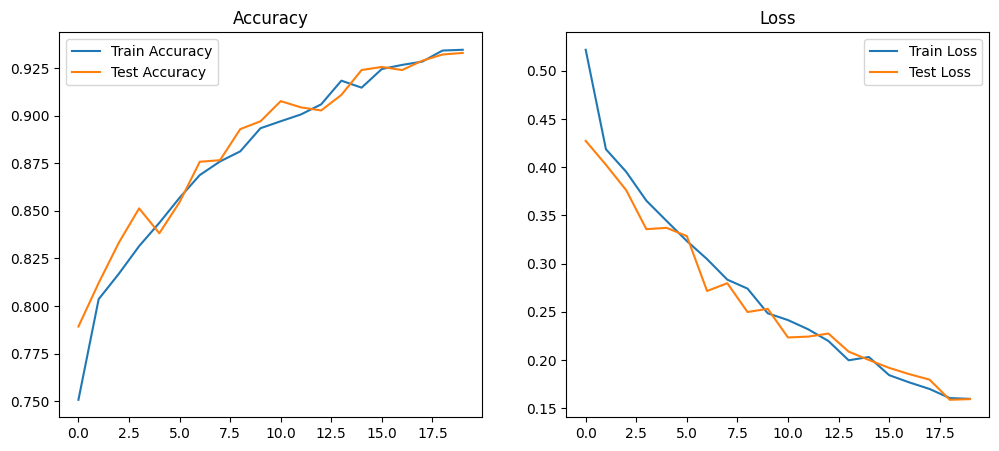

In [ ]:
# === VISUALIZE TRAINING ===
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_no_aug.history["accuracy"], label="Train Accuracy")
plt.plot(history_no_aug.history["val_accuracy"], label="Test Accuracy")
plt.title("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_no_aug.history["loss"], label="Train Loss")
plt.plot(history_no_aug.history["val_loss"], label="Test Loss")
plt.title("Loss")
plt.legend()

plt.show()

39/39 ━━━━━━━━━━━━━━━━━━━━ 16s 277ms/step
              precision    recall  f1-score   support

    autistic       0.95      0.96      0.95       692
non-autistic       0.95      0.93      0.94       532

    accuracy                           0.95      1224
   macro avg       0.95      0.94      0.95      1224
weighted avg       0.95      0.95      0.95      1224



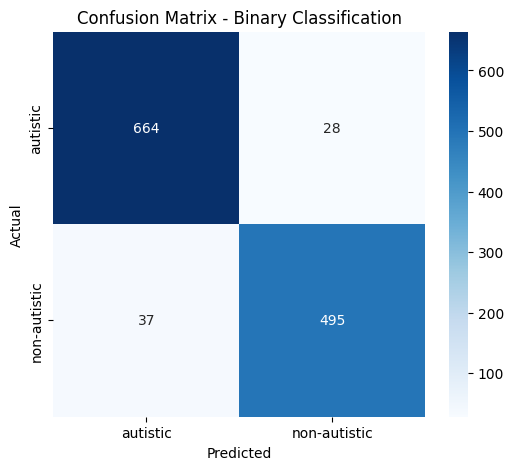

In [ ]:
# 1. Ambil prediksi dalam bentuk probabilitas (0.0 sampai 1.0)
y_pred = model.predict(test_gen_no_aug)

# 2. Ubah probabilitas jadi 0 atau 1 pake threshold 0.5
# Jangan pake argmax buat binary (1 output node)!
y_pred_class = (y_pred > 0.5).astype("int32").flatten()

# 3. Ambil label asli (ground truth)
y_true = test_gen_no_aug.classes  
class_labels = list(test_gen_no_aug.class_indices.keys())

# Sekarang print report-nya, pasti lebih masuk akal
print(classification_report(y_true, y_pred_class, target_names=class_labels))

# =============================
#  CONFUSION MATRIX
# =============================
cm = confusion_matrix(y_true, y_pred_class)

# Visualisasi tetep sama, tapi isinya udah bener
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.title("Confusion Matrix - Binary Classification")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()